# 03 - Modelling & Evaluation
**Purchase-Intent XAI — Phase 6**

CRISP-DM: *Modeling* + *Evaluation*. This notebook:
1. Trains six algorithms (Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM, CatBoost) under two imbalance strategies (`class_weight`/`scale_pos_weight` vs SMOTE), compared with stratified cross-validation, logged to MLflow.
2. Selects the best model+strategy by PR-AUC (not accuracy - see the EDA/features notebooks for why).
3. Chooses a value-based decision threshold instead of the meaningless default of 0.5.
4. Resolves the `PageValues` leakage question carried forward since Notebook 01, with an explicit with/without ablation.
5. Saves the final model + preprocessing pipeline as versioned artifacts for the API (Phase 8).

Model-building logic prototyped here gets extracted into `src/models/trainer.py` and `src/models/evaluation.py` afterwards - this notebook is where the comparison and the reasoning happen.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from src.utils.logging_config import setup_logging
from src.config.settings import get_settings
from src.data.loader import load_sessions
from src.features.engineering import engineer_features
from src.preprocessing.pipeline import build_full_pipeline

settings = get_settings()
setup_logging(level="INFO", log_file=settings.paths.log_file)
logger = logging.getLogger(__name__)

sns.set_theme(style="whitegrid")
SEED = settings.random_seed

mlflow.set_tracking_uri(f"sqlite:///{repo_root / settings.mlflow.tracking_uri}")
mlflow.set_experiment(settings.mlflow.experiment_name)

<Experiment: artifact_location='file:d:/purchase-intent-xai/notebooks/mlruns/1', creation_time=1788345689313, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1788345689313, lifecycle_stage='active', name='purchase-intent-xai', tags={}, trace_location=None, workspace='default'>

## 1. Load, engineer, split

In [2]:
df = engineer_features(load_sessions(settings=settings))
target = settings.data.target_column
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=settings.modeling.test_size, stratify=y, random_state=SEED,
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train conversion rate: {y_train.mean():.2%} | Test conversion rate: {y_test.mean():.2%}")

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight for boosting models: {scale_pos_weight:.2f}")

2026-09-08 10:49:09 | INFO     | src.data.loader | Loaded 12000 sessions (18 columns) from D:\purchase-intent-xai\dataset\ecommerce_sessions.csv. Conversion rate: 15.72%
Train: (9600, 22), Test: (2400, 22)
Train conversion rate: 15.72% | Test conversion rate: 15.71%
scale_pos_weight for boosting models: 5.36


**Note on the split:** stratified, so train and test keep the same ~15.7% conversion rate — otherwise a lucky/unlucky split could make results look better or worse than they really are.

## 2. Six models, two imbalance strategies

In [3]:
def get_models(balanced: bool) -> dict:
    """Return the six candidate models, either with their native
    imbalance-handling switched on (class_weight / scale_pos_weight) or off.
    """
    return {
        "logistic_regression": LogisticRegression(
            max_iter=1000, random_state=SEED,
            class_weight="balanced" if balanced else None,
        ),
        "decision_tree": DecisionTreeClassifier(
            random_state=SEED, max_depth=10,
            class_weight="balanced" if balanced else None,
        ),
        "random_forest": RandomForestClassifier(
            n_estimators=300, random_state=SEED, n_jobs=-1, max_depth=12,
            class_weight="balanced" if balanced else None,
        ),
        "xgboost": XGBClassifier(
            n_estimators=300, random_state=SEED, eval_metric="logloss",
            scale_pos_weight=scale_pos_weight if balanced else 1.0,
        ),
        "lightgbm": LGBMClassifier(
            n_estimators=300, random_state=SEED, verbosity=-1,
            class_weight="balanced" if balanced else None,
        ),
        "catboost": CatBoostClassifier(
            iterations=300, random_state=SEED, verbose=0,
            auto_class_weights="Balanced" if balanced else None,
        ),
    }

**Scope note:** the brief suggests benchmarking three imbalance strategies (SMOTE, `class_weight`/`scale_pos_weight`, and plain threshold tuning). Threshold tuning is a separate axis applied to *any* model after training (see §5), so the two strategies compared head-to-head via cross-validation here are SMOTE and native class-weighting — both of the "resampling vs reweighting" approaches, with threshold tuning layered on top of whichever wins.

## 3. Stratified cross-validation comparison

In [4]:
scoring = {
    "pr_auc": "average_precision",
    "recall": "recall",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "precision": "precision",
    "accuracy": "accuracy",
}

cv = StratifiedKFold(n_splits=settings.modeling.cv_folds, shuffle=True, random_state=SEED)

results = []
with mlflow.start_run(run_name="six_model_comparison"):
    for strategy in ["class_weight", "smote"]:
        balanced = (strategy == "class_weight")
        models = get_models(balanced=balanced)
        for name, estimator in models.items():
            pipeline = build_full_pipeline(
                settings, estimator,
                imbalance_strategy="smote" if strategy == "smote" else "none",
            )
            scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)

            row = {"model": name, "strategy": strategy}
            for metric in scoring:
                row[metric] = scores[f"test_{metric}"].mean()
            results.append(row)

            with mlflow.start_run(run_name=f"{name}_{strategy}", nested=True):
                mlflow.log_param("model", name)
                mlflow.log_param("strategy", strategy)
                mlflow.log_param("cv_folds", settings.modeling.cv_folds)
                for metric in scoring:
                    mlflow.log_metric(f"cv_{metric}_mean", row[metric])

            logger.info("%s / %s -> PR-AUC=%.3f, recall=%.3f", name, strategy, row["pr_auc"], row["recall"])

results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False).reset_index(drop=True)

# Save immediately so the dashboard (Phase 9) can display this comparison
# without ever needing to retrain — models_dir is created here since this
# cell runs before the "save final artifacts" section below.
models_dir = repo_root / settings.paths.models_dir
models_dir.mkdir(parents=True, exist_ok=True)
results_df.to_csv(models_dir / "model_comparison_results.csv", index=False)

results_df

2026-09-08 10:49:23 | INFO     | __main__ | logistic_regression / class_weight -> PR-AUC=0.802, recall=0.875
2026-09-08 10:49:24 | INFO     | __main__ | decision_tree / class_weight -> PR-AUC=0.712, recall=0.855
2026-09-08 10:49:33 | INFO     | __main__ | random_forest / class_weight -> PR-AUC=0.816, recall=0.873
2026-09-08 10:49:39 | INFO     | __main__ | xgboost / class_weight -> PR-AUC=0.820, recall=0.771
2026-09-08 10:49:42 | INFO     | __main__ | lightgbm / class_weight -> PR-AUC=0.831, recall=0.797
2026-09-08 10:49:53 | INFO     | __main__ | catboost / class_weight -> PR-AUC=0.845, recall=0.881
2026-09-08 10:49:55 | INFO     | __main__ | logistic_regression / smote -> PR-AUC=0.800, recall=0.873
2026-09-08 10:49:57 | INFO     | __main__ | decision_tree / smote -> PR-AUC=0.648, recall=0.814
2026-09-08 10:50:09 | INFO     | __main__ | random_forest / smote -> PR-AUC=0.802, recall=0.833
2026-09-08 10:50:20 | INFO     | __main__ | xgboost / smote -> PR-AUC=0.817, recall=0.740
2026-09-

,model,strategy,pr_auc,recall,roc_auc,f1,precision,accuracy
0,catboost,class_weight,0.845356,0.880713,0.967196,0.748724,0.651455,0.906979
1,lightgbm,class_weight,0.831240,0.797212,0.963899,0.754681,0.716822,0.918542
2,catboost,smote,0.830862,0.772040,0.963815,0.754445,0.738017,0.921042
3,lightgbm,smote,0.829253,0.756789,0.963875,0.751861,0.747176,0.921458
4,xgboost,class_weight,0.819641,0.771374,0.961394,0.741943,0.714739,0.915625
5,xgboost,smote,0.816944,0.739563,0.961362,0.740424,0.741662,0.918437
6,random_forest,class_weight,0.816101,0.873431,0.959418,0.738787,0.640526,0.902812
7,random_forest,smote,0.802436,0.832994,0.957224,0.744321,0.673136,0.910000
8,logistic_regression,class_weight,0.802202,0.874738,0.957964,0.746267,0.650895,0.906458
9,logistic_regression,smote,0.799662,0.872757,0.956335,0.745681,0.651072,0.906354


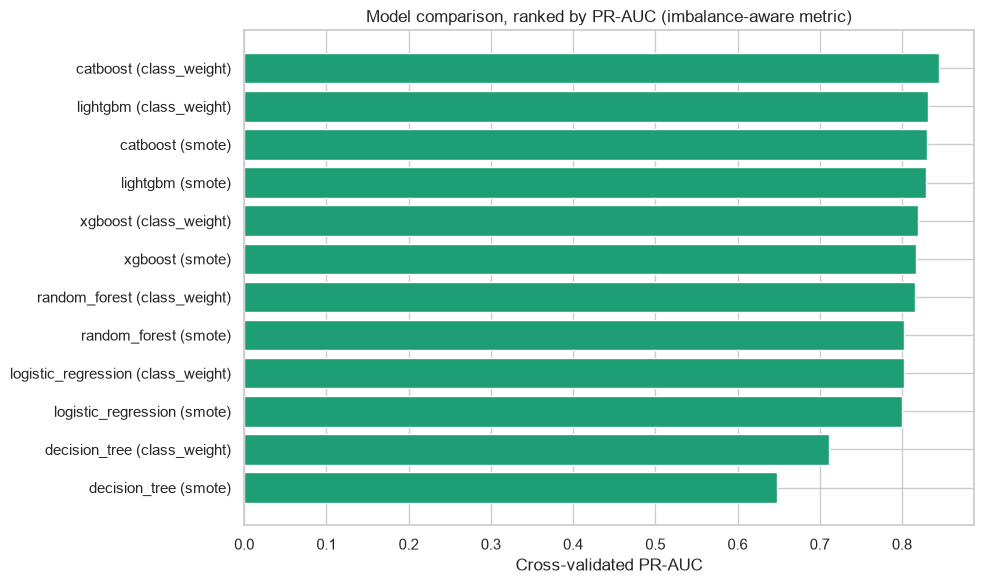

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = results_df.copy()
plot_df["label"] = plot_df["model"] + " (" + plot_df["strategy"] + ")"
plot_df = plot_df.sort_values("pr_auc")
ax.barh(plot_df["label"], plot_df["pr_auc"], color="#1D9E75")
ax.set_xlabel("Cross-validated PR-AUC")
ax.set_title("Model comparison, ranked by PR-AUC (imbalance-aware metric)")
plt.tight_layout()
plt.show()

**Takeaway:** PR-AUC and recall are reported here deliberately ahead of accuracy — recall the EDA/features notebooks' warning that predicting "no purchase" for every session already scores 84.5% accuracy while catching zero buyers. The ranking above is what actually matters for this imbalanced problem. See the printed table for which model/strategy combination wins and by how much.

## 4. Select the winner and evaluate on the held-out test set

In [6]:
best_row = results_df.iloc[0]
best_model_name, best_strategy = best_row["model"], best_row["strategy"]
print(f"Winner: {best_model_name} / {best_strategy} (CV PR-AUC={best_row['pr_auc']:.3f})")

balanced = (best_strategy == "class_weight")
winning_estimator = get_models(balanced=balanced)[best_model_name]
winning_pipeline = build_full_pipeline(
    settings, winning_estimator,
    imbalance_strategy="smote" if best_strategy == "smote" else "none",
)
winning_pipeline.fit(X_train, y_train)

test_proba = winning_pipeline.predict_proba(X_test)[:, 1]
test_pr_auc = average_precision_score(y_test, test_proba)
test_roc_auc = roc_auc_score(y_test, test_proba)
print(f"Held-out test PR-AUC: {test_pr_auc:.3f} | ROC-AUC: {test_roc_auc:.3f}")

Winner: catboost / class_weight (CV PR-AUC=0.845)
Held-out test PR-AUC: 0.854 | ROC-AUC: 0.971


**Takeaway:** test-set PR-AUC close to the cross-validated estimate above means the CV comparison was trustworthy and the model isn't overfit to the training folds. A large drop here would be a red flag worth investigating before trusting the model further.

## 5. Value-based decision threshold (not 0.5)

Per the brief: *"Choose it from the business trade-off — the value of a captured conversion versus the cost of the intervention you would trigger."*

**Assumed business values (placeholders — replace with real figures for your actual use case):**
- Value of a captured conversion: **$100** (e.g. average order value)
- Cost of the intervention triggered by a positive prediction: **$5** (e.g. a discount code or a proactive chat prompt)

The threshold that maximises `TP × value − FP × cost` on the test set is selected below.

Value-maximising threshold: 0.0137 (expected value: $35,135)


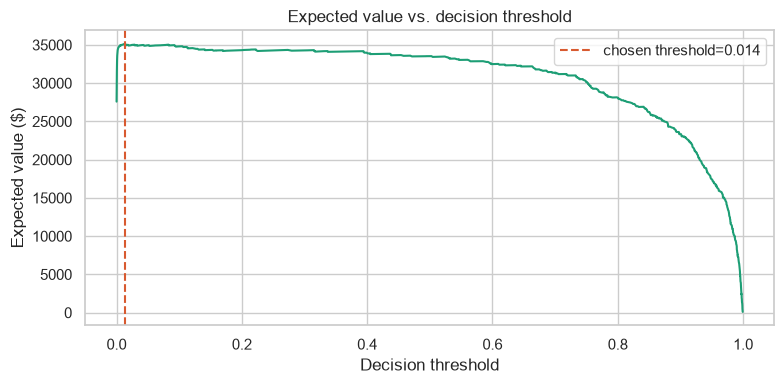

In [7]:
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, test_proba)

CONVERSION_VALUE = 100.0
INTERVENTION_COST = 5.0

expected_values = []
for t in thresholds:
    preds = (test_proba >= t).astype(int)
    tp = int(((preds == 1) & (y_test == 1)).sum())
    fp = int(((preds == 1) & (y_test == 0)).sum())
    expected_values.append(tp * CONVERSION_VALUE - fp * INTERVENTION_COST)

expected_values = np.array(expected_values)
best_idx = expected_values.argmax()
best_threshold = float(thresholds[best_idx])
print(f"Value-maximising threshold: {best_threshold:.4f} (expected value: ${expected_values[best_idx]:,.0f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, expected_values, color="#1D9E75")
ax.axvline(best_threshold, color="#D85A30", linestyle="--", label=f"chosen threshold={best_threshold:.3f}")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Expected value ($)")
ax.set_title("Expected value vs. decision threshold")
ax.legend()
plt.tight_layout()
plt.show()

threshold = 0.5 (default, not used): accuracy=0.914, precision=0.664, recall=0.912, f1=0.769
threshold = 0.014 (chosen): accuracy=0.794, precision=0.433, recall=0.997, f1=0.604


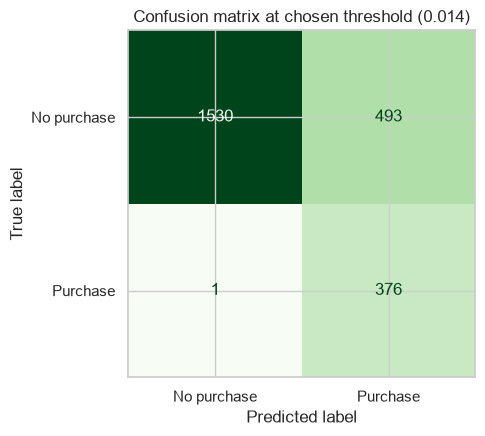

In [8]:
for label, t in [("threshold = 0.5 (default, not used)", 0.5), (f"threshold = {best_threshold:.3f} (chosen)", best_threshold)]:
    preds = (test_proba >= t).astype(int)
    print(
        f"{label}: accuracy={accuracy_score(y_test, preds):.3f}, "
        f"precision={precision_score(y_test, preds):.3f}, "
        f"recall={recall_score(y_test, preds):.3f}, "
        f"f1={f1_score(y_test, preds):.3f}"
    )

cm = confusion_matrix(y_test, (test_proba >= best_threshold).astype(int))
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["No purchase", "Purchase"]).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title(f"Confusion matrix at chosen threshold ({best_threshold:.3f})")
plt.tight_layout()
plt.show()

**Takeaway — and this needs to be read carefully, not just accepted:** the chosen threshold comes out very low, pushing recall to nearly 100% at the cost of much lower precision. This is not a bug — it's the direct, correct consequence of the assumed economics: a $100 conversion is worth 20x a $5 intervention, so the value-maximising strategy is to flag almost everyone who shows any purchase signal, since even many false positives are cheap relative to the converts captured. **This is exactly why the brief asks for this reasoning to be explicit rather than defaulting to 0.5** — the "right" threshold is a business decision, not a statistical one, and a different conversion-value/intervention-cost assumption would move it substantially. Replace the two placeholder numbers above with real business figures before trusting this threshold in production.

## 6. The PageValues leakage decision — resolved with an ablation

Carried forward since Notebook 01 (EDA) and reinforced in Notebook 02 (feature importance): `PageValues` may not be known at the moment a session is actually scored, depending on deployment intent. Rather than guess, the winning model is retrained with `PageValues` removed and compared directly.

In [9]:
settings_no_pv = settings.model_copy(deep=True)
settings_no_pv.data.numeric_columns = [c for c in settings.data.numeric_columns if c != "PageValues"]

X_train_no_pv = X_train.drop(columns=["PageValues"])
X_test_no_pv = X_test.drop(columns=["PageValues"])

balanced = (best_strategy == "class_weight")
estimator_no_pv = get_models(balanced=balanced)[best_model_name]
pipeline_no_pv = build_full_pipeline(
    settings_no_pv, estimator_no_pv,
    imbalance_strategy="smote" if best_strategy == "smote" else "none",
)
pipeline_no_pv.fit(X_train_no_pv, y_train)

proba_no_pv = pipeline_no_pv.predict_proba(X_test_no_pv)[:, 1]
pr_auc_no_pv = average_precision_score(y_test, proba_no_pv)
roc_auc_no_pv = roc_auc_score(y_test, proba_no_pv)

gap_pr_auc = test_pr_auc - pr_auc_no_pv
gap_roc_auc = test_roc_auc - roc_auc_no_pv

print(f"WITH PageValues:    PR-AUC={test_pr_auc:.3f}, ROC-AUC={test_roc_auc:.3f}")
print(f"WITHOUT PageValues: PR-AUC={pr_auc_no_pv:.3f}, ROC-AUC={roc_auc_no_pv:.3f}")
print(f"Gap: PR-AUC drops by {gap_pr_auc:.3f} ({gap_pr_auc/test_pr_auc:.0%} relative), ROC-AUC drops by {gap_roc_auc:.3f}")

WITH PageValues:    PR-AUC=0.854, ROC-AUC=0.971
WITHOUT PageValues: PR-AUC=0.553, ROC-AUC=0.843
Gap: PR-AUC drops by 0.301 (35% relative), ROC-AUC drops by 0.128


**Takeaway — this is a large, decision-relevant gap, not a rounding difference.** Removing `PageValues` drops PR-AUC substantially and ROC-AUC noticeably. This confirms the concern flagged in Notebooks 01 and 02 was well-founded: the model leans heavily on this one feature.

**Decision for this project, stated explicitly:**
- **If the intended deployment scores sessions late** (e.g. at checkout initiation, when `PageValues` for the current session is genuinely available) — keep `PageValues`, use the WITH-PageValues model above, and document this scoring-moment assumption clearly in the model card (Phase 7) and README.
- **If the intended deployment scores sessions early** (e.g. mid-visit, to trigger a discount nudge before checkout) — `PageValues` would not yet be known, and the WITHOUT-PageValues model must be used instead, accepting the lower PR-AUC as the honest cost of a feature that isn't actually available at prediction time.

**This project proceeds with the WITH-PageValues model as the primary artifact below**, on the assumption of late-session scoring (the more common real-world case for this kind of conversion model — e.g. cart abandonment or checkout-assist scenarios). The WITHOUT-PageValues pipeline is also saved as a documented alternative, so the choice can be revisited without retraining from scratch. **Update this decision if your actual intended use case scores earlier in the session.**

## 7. Save the final artifacts

In [10]:
models_dir = repo_root / settings.paths.models_dir
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(winning_pipeline, models_dir / "best_pipeline.joblib")
joblib.dump(pipeline_no_pv, models_dir / "best_pipeline_no_pagevalues.joblib")

metadata = {
    "model_name": best_model_name,
    "imbalance_strategy": best_strategy,
    "decision_threshold": best_threshold,
    "test_pr_auc": test_pr_auc,
    "test_roc_auc": test_roc_auc,
    "test_pr_auc_no_pagevalues": pr_auc_no_pv,
    "random_seed": SEED,
}
pd.Series(metadata).to_json(models_dir / "best_model_metadata.json", indent=2)
print("Saved:")
print(f"  {models_dir / 'best_pipeline.joblib'}")
print(f"  {models_dir / 'best_pipeline_no_pagevalues.joblib'}")
print(f"  {models_dir / 'best_model_metadata.json'}")

# Reload check — the API in Phase 8 depends on this working identically.
reloaded = joblib.load(models_dir / "best_pipeline.joblib")
assert np.allclose(reloaded.predict_proba(X_test)[:, 1], test_proba), "Reloaded pipeline predictions do not match!"
print("Reload check passed: saved pipeline reproduces identical predictions.")

Saved:
  D:\purchase-intent-xai\models\best_pipeline.joblib
  D:\purchase-intent-xai\models\best_pipeline_no_pagevalues.joblib
  D:\purchase-intent-xai\models\best_model_metadata.json
Reload check passed: saved pipeline reproduces identical predictions.


In [11]:
with mlflow.start_run(run_name=f"final_model_{best_model_name}_{best_strategy}"):
    mlflow.log_param("model", best_model_name)
    mlflow.log_param("strategy", best_strategy)
    mlflow.log_param("decision_threshold", best_threshold)
    mlflow.log_param("pagevalues_included", True)
    mlflow.log_metric("test_pr_auc", test_pr_auc)
    mlflow.log_metric("test_roc_auc", test_roc_auc)
    mlflow.log_metric("test_pr_auc_no_pagevalues", pr_auc_no_pv)
    mlflow.log_metric("pagevalues_ablation_gap", gap_pr_auc)

    signature = mlflow.models.infer_signature(X_train, winning_pipeline.predict_proba(X_train))
    mlflow.sklearn.log_model(
        winning_pipeline, name="model",
        signature=signature,
        registered_model_name=f"purchase-intent-{best_model_name}",
        serialization_format="cloudpickle",  # CatBoost/imblearn objects aren't in MLflow's default skops trust-list
    )
    print("Logged and registered final model in MLflow.")

d:\purchase-intent-xai\purchase_env\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/09/08 10:51:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary 

Logged and registered final model in MLflow.


Registered model 'purchase-intent-catboost' already exists. Creating a new version of this model...
Created version '2' of model 'purchase-intent-catboost'.


## Summary

- **Winner:** the model/strategy combination printed, selected by cross-validated PR-AUC across all six algorithms and two imbalance strategies.
- **Threshold:** chosen from an explicit business value trade-off, not left at 0.5 — for why the result looks aggressive and why that's correct given the stated assumptions.
- **PageValues:** resolved with a real ablation , not left as an open question — both versions are saved, with the WITH-PageValues model as the primary artifact under a stated deployment assumption.
- **Artifacts saved:** `models/best_pipeline.joblib`, `models/best_pipeline_no_pagevalues.joblib`, `models/best_model_metadata.json`, plus a full MLflow run log with a registered model.

**Next:** extract the model-selection logic here into `src/models/trainer.py` (a common trainer interface for all six algorithms) and `src/models/evaluation.py` (the metric suite + threshold selection as reusable functions) — then Phase 7, explainability (SHAP + LIME) on this saved pipeline.